In [1]:
# Import the Cirq Library
import cirq

In [2]:
# Get two qubits, a data qubit and target qubit, respectively
q0, q1 = cirq.LineQubit.range(2)

In [4]:
# Dictionary of oracles
oracles = {'0':[],'1':[cirq.X(q1)], 'x':[cirq.CNOT(q0,q1)], 'notx':[cirq.CNOT(q0,q1), cirq.X(q1)]}

In [9]:
def deutsch_algorithm(oracle):
    """Yields a circuit for Deutsch's algorithm given operations implementing the oracle"""
    yield cirq.X(q1)
    yield cirq.H(q0), cirq.H(q1)
    yield oracle
    yield cirq.H(q0)
    yield cirq.measure(q0)
    

In [12]:
# Display each circuit for all oracles
for key, oracle in oracles.items():
    print('Circuit for {}:'.format(key))
    print(cirq.Circuit(list(deutsch_algorithm(oracle))))

Circuit for 0:
0: ───H───H───M───

1: ───X───H───────
Circuit for 1:
0: ───H───H───M───

1: ───X───H───X───
Circuit for x:
0: ───H───────@───H───M───
              │
1: ───X───H───X───────────
Circuit for notx:
0: ───H───────@───H───M───
              │
1: ───X───H───X───X───────


In [13]:
# Get a simulator 
simulator = cirq.Simulator()

In [16]:
# Execute the circuit for each oracle to distinguish constant from balanced
for key, oracle in oracles.items():
    result = simulator.run(
        cirq.Circuit(list(deutsch_algorithm(oracle))),
        repetitions=10
    )
    print('oracle: {} results: {}'.format(key, result))

oracle: 0 results: q(0)=0000000000
oracle: 1 results: q(0)=0000000000
oracle: x results: q(0)=1111111111
oracle: notx results: q(0)=1111111111


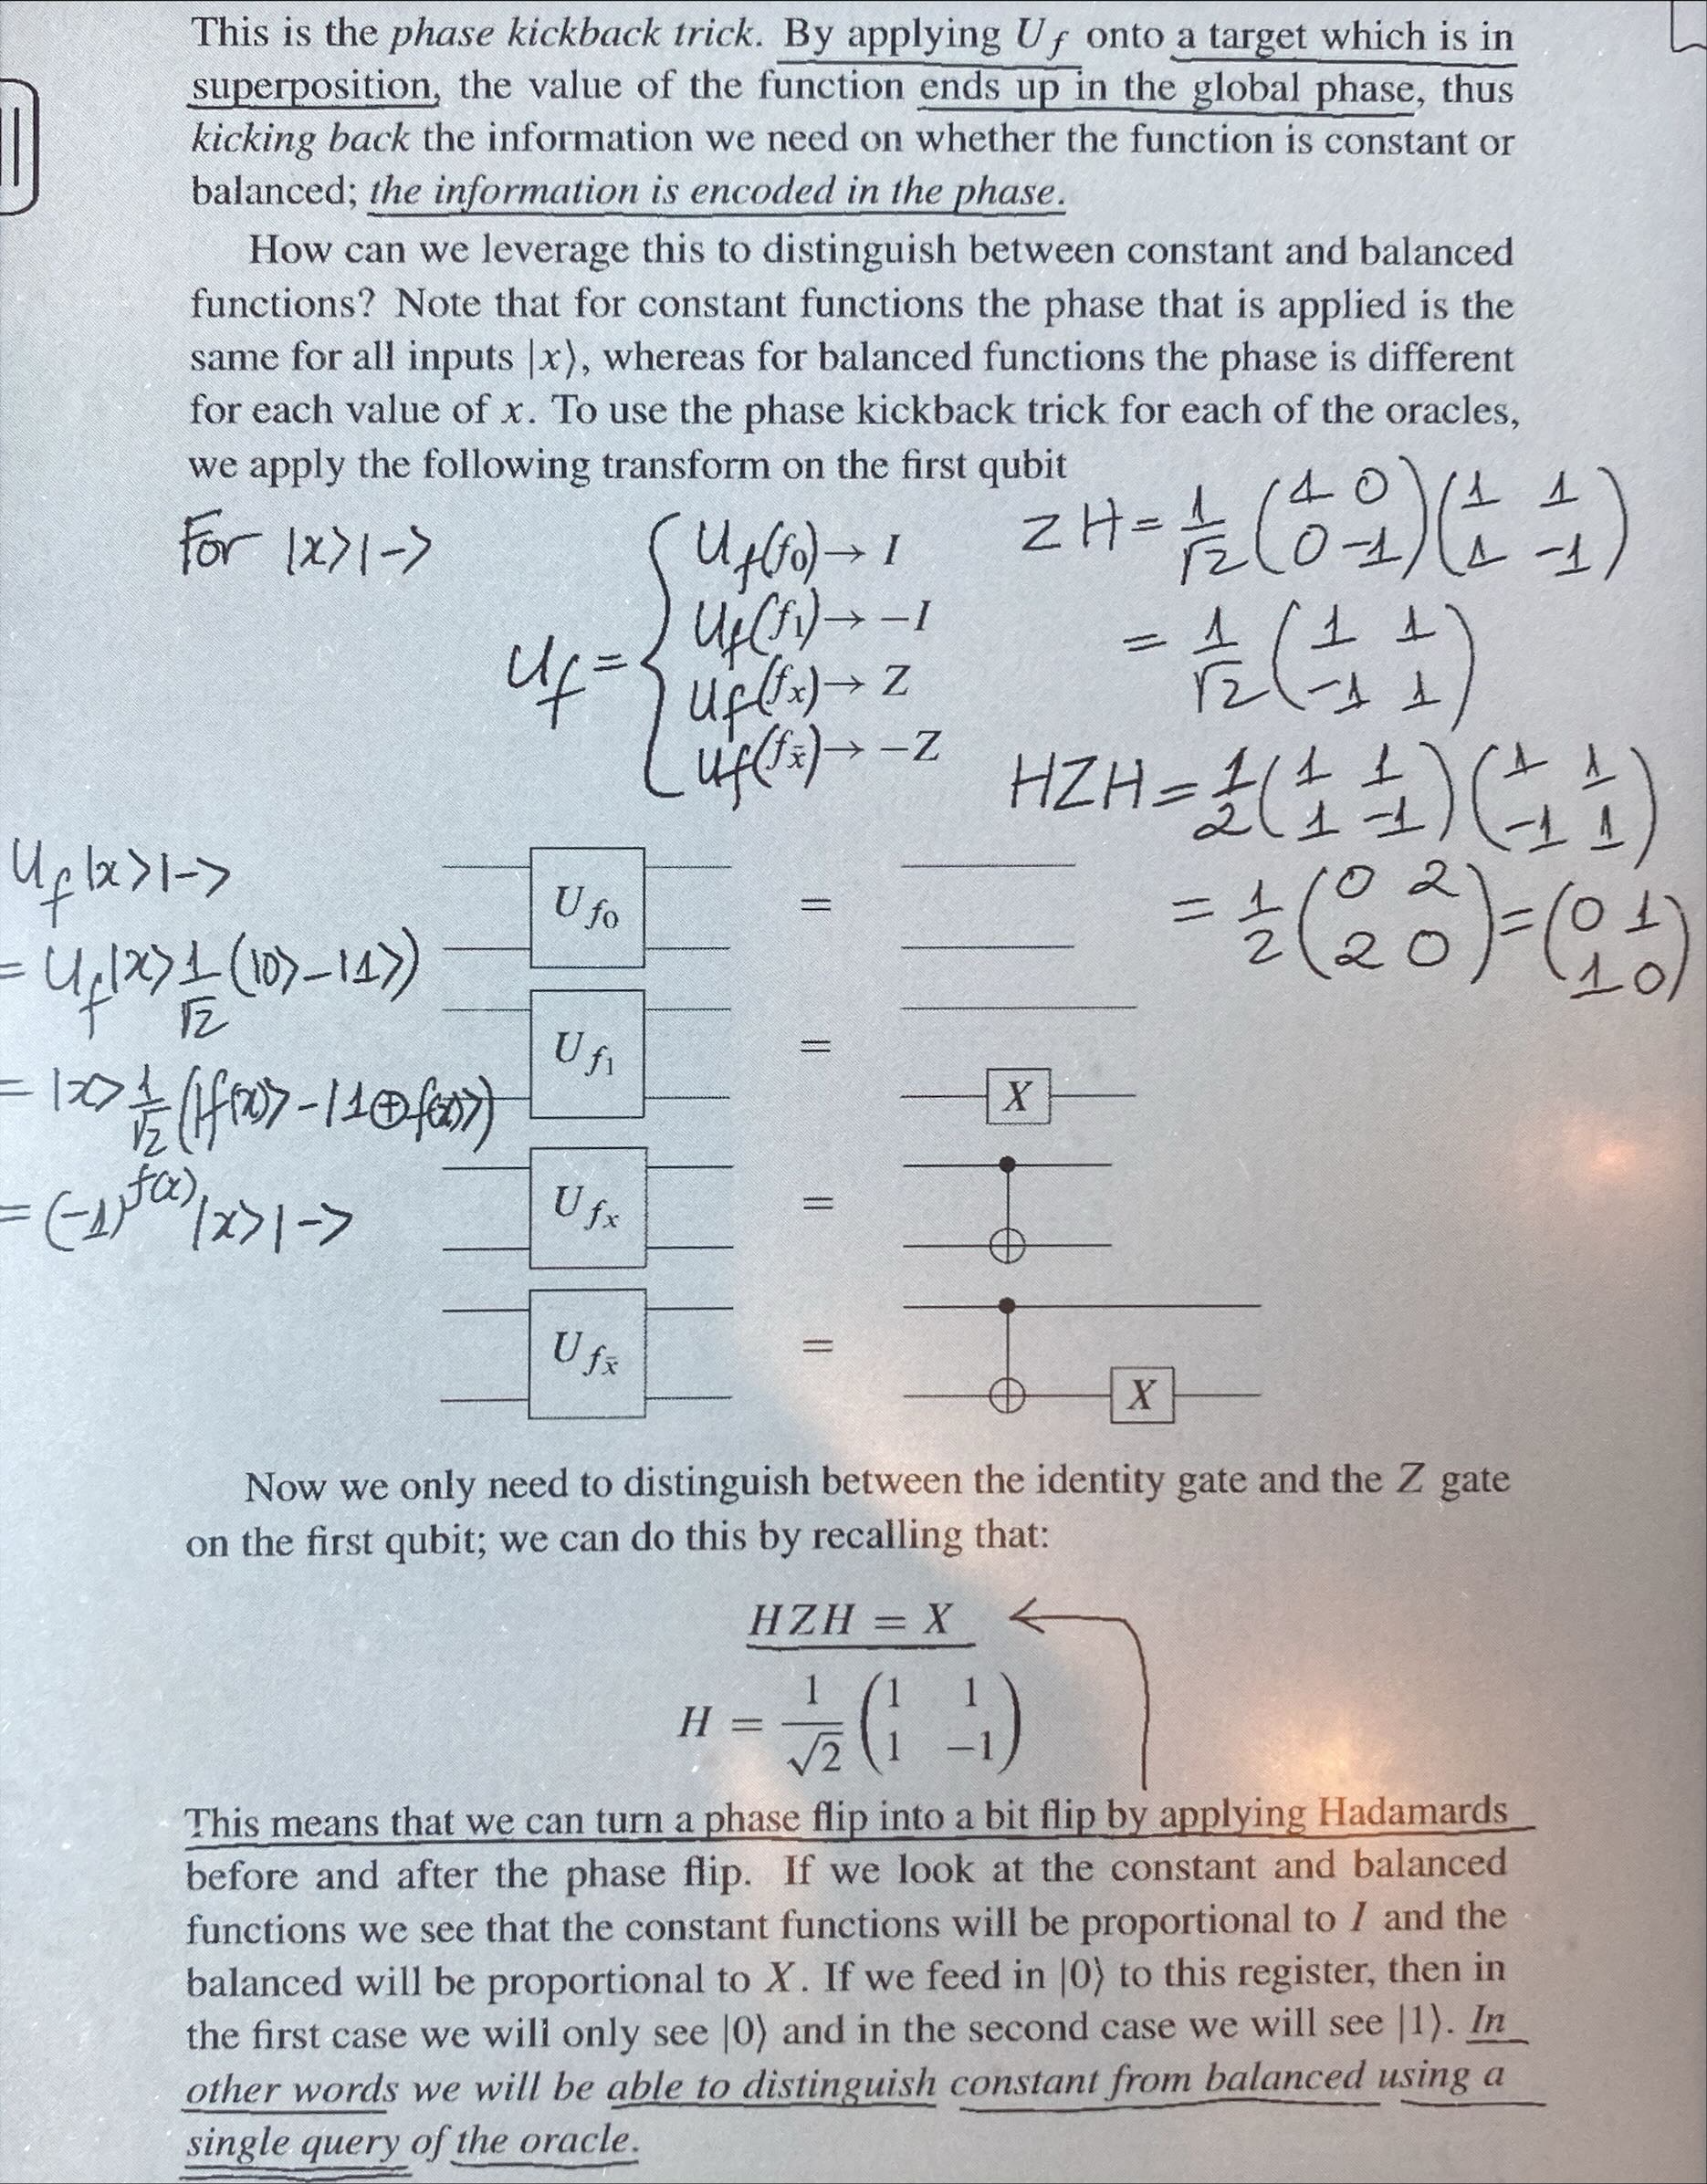

In [1]:
# Import the Cirq library
import cirq

In [2]:
# Get three qubits -- two data and one target qubit
q0, q1, q2 = cirq.LineQubit.range(3)

In [3]:
# Oracles for constant functions
constant = ([], [cirq.X(q2)])

In [13]:
# Oracles for balanced functions
balanced = ([cirq.CNOT(q0, q2)],
            [cirq.CNOT(q1, q2)],
            [cirq.CNOT(q0, q2), cirq.CNOT(q1, q2)],
            [cirq.CNOT(q0, q2), cirq.X(q2)],
            [cirq.CNOT(q1, q2), cirq.X(q2)],
            [cirq.CNOT(q0, q2), cirq.CNOT(q1, q2), cirq.X(q2)])

In [14]:
def your_circuit(oracle):
    # phase kickback trick
    yield cirq.X(q2), cirq.H(q2)
    # equal superposition over input bits
    yield cirq.H(q0), cirq.H(q1)
    # query the function
    yield oracle
    # Apply Hadamard gate
    yield cirq.H(q0), cirq.H(q1)
    yield cirq.measure([q0,q1],key="z")
    

In [15]:
simulator = cirq.Simulator()

In [16]:
i = 0
for oracle in constant:
    i = i+1
    print("Constants: ", i)
    res = simulator.run(cirq.Circuit(your_circuit(oracle)), repetitions=10)
    print("\nMeasurements:")
    print(res.histogram(key="z"))

Constants:  1

Measurements:
Counter({0: 10})
Constants:  2

Measurements:
Counter({0: 10})


In [17]:
i = 0
for oracle in balanced:
    i = i+1
    print("Balance: ", i)
    res = simulator.run(cirq.Circuit(your_circuit(oracle)), repetitions=10)
    print("\nMeasurements:")
    print(res.histogram(key="z"))

Balance:  1

Measurements:
Counter({2: 10})
Balance:  2

Measurements:
Counter({1: 10})
Balance:  3

Measurements:
Counter({3: 10})
Balance:  4

Measurements:
Counter({2: 10})
Balance:  5

Measurements:
Counter({1: 10})
Balance:  6

Measurements:
Counter({3: 10})
